# Language model

Today AI chat assistants are everywhere, name it ChatGPT, Gemini, Claude, etc. But how would one even think of making such a thing. Well all of them are language models i.e. models that understand and predict the next word in a given sequence. A bigram is one of the earliest language models.

A *bigram* (or digram) is a sequence of two adjacent elements, usually words or characters, from a text, forming pairs like "hello world" or "th", used in Natural Language Processing (NLP) to model language by predicting the next element based on the previous one, calculating probabilities from their frequency in a corpus (a text dataset).

**Example (Words):** In "The quick brown fox", bigrams are ("The", "quick"), ("quick", "brown"), ("brown", "fox").  
**Example (Characters):** In "cat", bigrams are ("c", "a"), ("a", "t").  

A bigram model calculates the probability of a word **B** following word **A**, often by dividing the count of the **AB** sequence by the count of word **A**. 

**Example with a small corpus**  

**Corpus:** "The cat sat on the mat. The dog chased the cat."  

**Count Unigrams (single words):**   
"The": 3  
"cat": 2  
"sat": 1  
"on": 1  
"the": 2 (lowercase)  
"mat": 1  
"dog": 1  
"chased": 1  

**Count Bigrams (word pairs):**  
"The cat": 2  
"cat sat": 1  
"sat on": 1  
"on the": 1  
"the mat": 1  
"The dog": 1  
"dog chased": 1  
"chased the": 1  

**Calculate Conditional Probabilities:**  
P("cat" | "The") = Count("The cat") / Count("The") = 2 / 3 ≈ 0.67  
P("sat" | "cat") = Count("cat sat") / Count("cat") = 1 / 2 = 0.5  
P("dog" | "The") = Count("The dog") / Count("The") = 1 / 3 ≈ 0.33  

**Calculate Sentence Probability:**  
For "The cat sat": P("The cat") * P("cat sat") = (2/3) * (1/2) = 1/3 ≈ 0.33. 

---

## 1. Creating a bigram language model

To create a bigram language model:
1. First we need a corpus, in our case its `names.txt`. A small dataset of names.
2. Then we need to create all possible bigrams out of this corpus, count their frequencies and store it.
3. Then we need to make a probability distribution table where each row represents the different probabilities for another character that can appear after the given character.

### 1.1 Loading and exploring the dataset

In [1]:
names = open("data/names.txt").read().splitlines()
names[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [2]:
print(f"Total names = {len(names)}")

Total names = 32033


### 1.2 Creating a bigram model

Since our corpus consists of single words (or names) only but no sentences, we will stick to **character level bigrams** only.

Also our names are made up of 26 alphabets so we can get possible bigram pairs from these 26 characters only. These pairs will only tell us what sort of other characters are more likely to follow a particular character but they doesn't tell us anything about the possibility of a character being a starting or an ending character. 

For example: Lets take names `emma` & `ava` so  
- bigrams for `emma` are `em`, `mm`, `ma` 
- bigrams for `ava` are `av`, `va` 

Notice "emma" and "ava" both ends with 'a'. But we can't count it as a bigram pair as there is no character after 'a'.

In [3]:
b = {}
for name in names[:2]:
    chars = list(name)
    for ch1, ch2 in zip(chars, chars[1:]):
        bigram = (ch1, ch2)
        print(bigram)


('e', 'm')
('m', 'm')
('m', 'a')
('o', 'l')
('l', 'i')
('i', 'v')
('v', 'i')
('i', 'a')


In order to emphasize the starting and ending of the character sequence in a given name we can add dummy characters `<s>` & `<e>` to our vocabulary to represent the start and end of a character sequence. 

Thus for the above example the names become `<s>emma<e>` & `<s>ava<e>` so  
- bigrams for `<s>emma<e>` are `<s>e`, `em`, `mm`, `ma`, `a<e>`    
- bigrams for `<s>ava<e>` are `<s>a` , `av`, `va`, `a<e>`

In [4]:
b = {}
for name in names:
    # adding '<s>' & '<e>' to represent starting and ending of character sequence in the given name
    chars = ['<s>'] + list(name) + ['<e>']
    print(chars)
    for ch1, ch2 in zip(chars, chars[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

['<s>', 'e', 'm', 'm', 'a', '<e>']
['<s>', 'o', 'l', 'i', 'v', 'i', 'a', '<e>']
['<s>', 'a', 'v', 'a', '<e>']
['<s>', 'i', 's', 'a', 'b', 'e', 'l', 'l', 'a', '<e>']
['<s>', 's', 'o', 'p', 'h', 'i', 'a', '<e>']
['<s>', 'c', 'h', 'a', 'r', 'l', 'o', 't', 't', 'e', '<e>']
['<s>', 'm', 'i', 'a', '<e>']
['<s>', 'a', 'm', 'e', 'l', 'i', 'a', '<e>']
['<s>', 'h', 'a', 'r', 'p', 'e', 'r', '<e>']
['<s>', 'e', 'v', 'e', 'l', 'y', 'n', '<e>']
['<s>', 'a', 'b', 'i', 'g', 'a', 'i', 'l', '<e>']
['<s>', 'e', 'm', 'i', 'l', 'y', '<e>']
['<s>', 'e', 'l', 'i', 'z', 'a', 'b', 'e', 't', 'h', '<e>']
['<s>', 'm', 'i', 'l', 'a', '<e>']
['<s>', 'e', 'l', 'l', 'a', '<e>']
['<s>', 'a', 'v', 'e', 'r', 'y', '<e>']
['<s>', 's', 'o', 'f', 'i', 'a', '<e>']
['<s>', 'c', 'a', 'm', 'i', 'l', 'a', '<e>']
['<s>', 'a', 'r', 'i', 'a', '<e>']
['<s>', 's', 'c', 'a', 'r', 'l', 'e', 't', 't', '<e>']
['<s>', 'v', 'i', 'c', 't', 'o', 'r', 'i', 'a', '<e>']
['<s>', 'm', 'a', 'd', 'i', 's', 'o', 'n', '<e>']
['<s>', 'l', 'u', 'n', 'a

In [5]:
# top 10 bigrams with the highest frequencies
sorted(b.items(), key=lambda item: item[1], reverse=True)[:10]

[(('n', '<e>'), 6763),
 (('a', '<e>'), 6640),
 (('a', 'n'), 5438),
 (('<s>', 'a'), 4410),
 (('e', '<e>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<s>', 'k'), 2963)]

Till now we have only created bigrams, counted their frequencies and stored it in a dictionary. But we can better visualize them using pytorch's tensors, specifically a 2-D tensor or a matrix where each row and column will represent all our unique characters and every cell of that matrix will represent the frequency count of the corresponding bigram pair.

Tensors in pytorch work with numeric values only so we need to represent/encode our characters as a number. We can do this by having a char-to-int mapping. We also need to have an int-to-char mapping to decode back the original characters. 

In [6]:
# get all unique characters in the text corpus
chars = sorted(set(''.join(names)))
# char to int mapping
ch_to_i = {ch: i for i, ch in enumerate(chars)} 
# adding dummy characters to represent start and end
ch_to_i['<s>'] = 26
ch_to_i['<e>'] = 27
# int to char mapping
i_to_ch = {i: ch for ch, i in ch_to_i.items()} 

vocab_size = len(ch_to_i)
print(f"no. of unique characters = {vocab_size}")

no. of unique characters = 28


In [7]:
print(f"encoder = {ch_to_i}")
print(f"decoder = {i_to_ch}")

encoder = {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'x': 23, 'y': 24, 'z': 25, '<s>': 26, '<e>': 27}
decoder = {0: 'a', 1: 'b', 2: 'c', 3: 'd', 4: 'e', 5: 'f', 6: 'g', 7: 'h', 8: 'i', 9: 'j', 10: 'k', 11: 'l', 12: 'm', 13: 'n', 14: 'o', 15: 'p', 16: 'q', 17: 'r', 18: 's', 19: 't', 20: 'u', 21: 'v', 22: 'w', 23: 'x', 24: 'y', 25: 'z', 26: '<s>', 27: '<e>'}


In [8]:
import torch

# default dtype of tensors in pytorch is float32
# we need to repesent frequency count of bigrams thus, using int32
# initializing the tensor with 0 so that any unseen bigram get 0 freq count
B = torch.zeros((vocab_size, vocab_size), dtype=torch.int32)

for name in names:
    chars = ['<s>'] + list(name) + ['<e>']
    for ch1, ch2 in zip(chars, chars[1:]):
        ix1 = ch_to_i[ch1]
        ix2 = ch_to_i[ch2]
        B[ix1, ix2] += 1

B[:2]

tensor([[ 556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568, 2528,
         1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,  182,
         2050,  435,    0, 6640],
        [ 321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,  103,
            0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,    0,
           83,    0,    0,  114]], dtype=torch.int32)

Here we are printing the first 2 rows of the tensor object **B**. 
- Row 0 represents character **a** and its columns represents the frequency count for bigrams where first character is **a**.
- Row 1 represents character **b** and its columns represents the frequency count for bigrams where first character is **b**.

In [9]:
B[0, 27].item() # same as bigram (('a', '<e>'), 6640) from the dictionary above.

6640

#### Visualizing the model

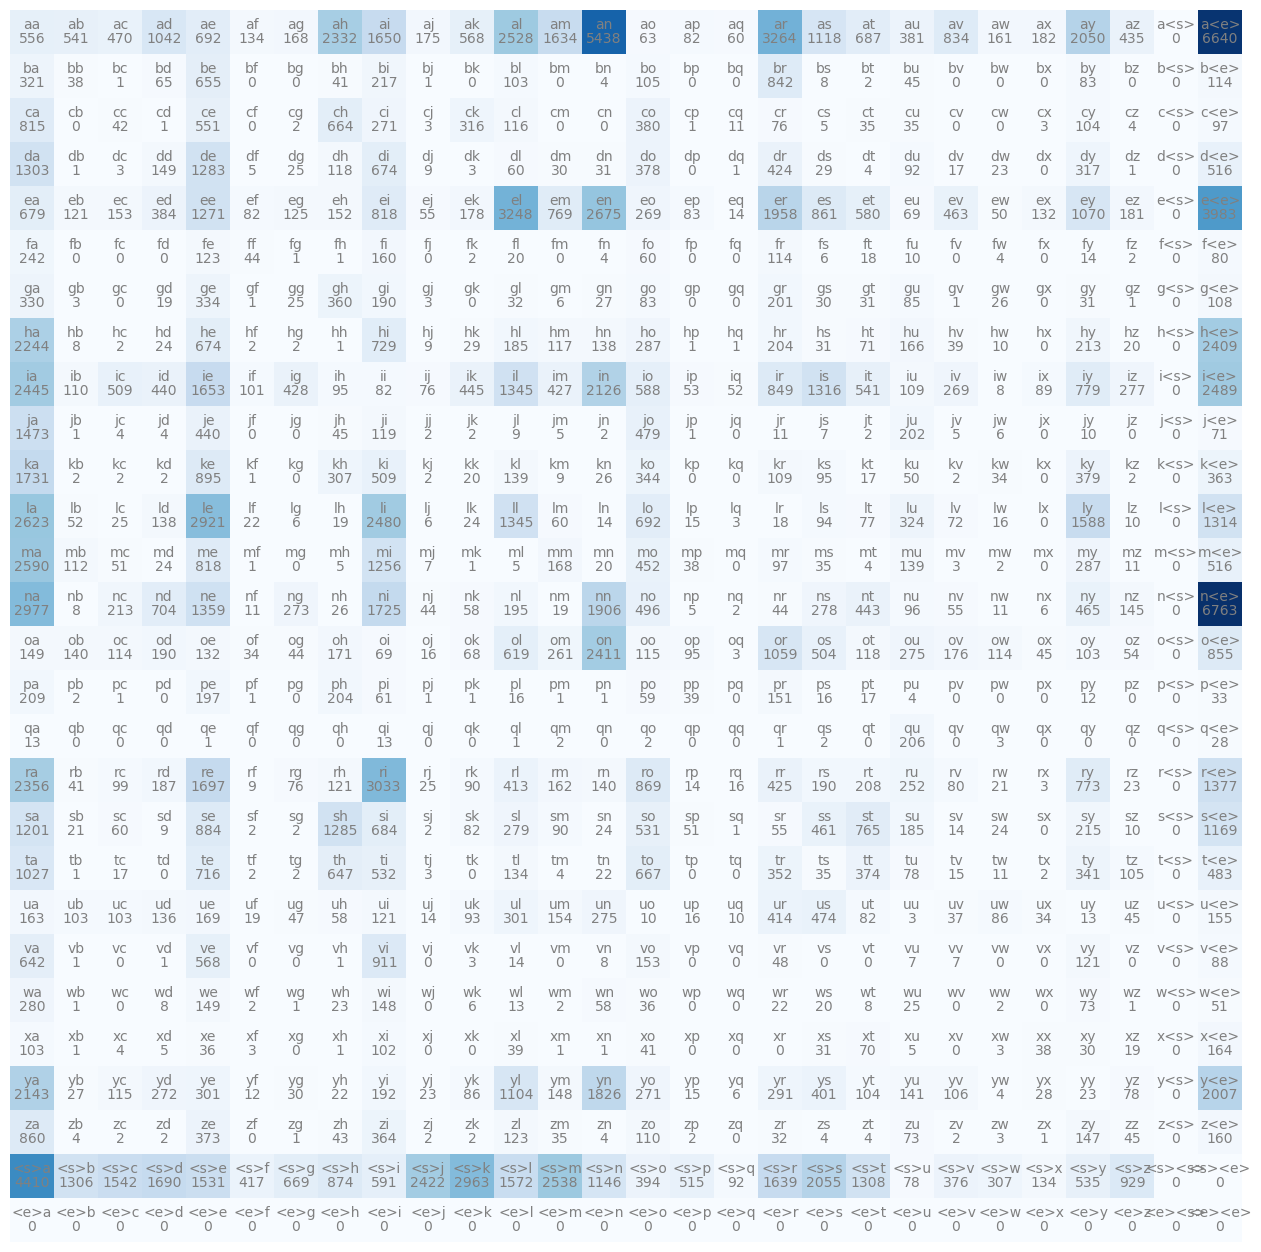

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,16))
plt.imshow(B, cmap='Blues')
for i in range(vocab_size):
    for j in range(vocab_size):
        ch = i_to_ch[i] + i_to_ch[j]
        plt.text(j, i, ch, ha="center", va="bottom", color='gray')
        plt.text(j, i, B[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off')
plt.show()

In the above graph, frequency counts of
1. bigrams ending with `<s>` like `a<s>`, `b<s>`, ... ,`z<s>` in the second last column are 0.
2. bigrams starting with `<e>` like `<e>a`, `<e>b`, ... ,`<e>z` in the last row are 0.
3. bigrams like `<s><s>`, `<s><e>`, `<e><s>` and `<e><e>` in bottom right are 0.

This observation is evident as a name would never
1. start with an ending charcter.
2. end with a starting character.

So its taking some extra space without giving any meaningful insights. Thus instead of using `<s>` & `<e>` as separate characters to represent the starting and ending of a character sequence we will just use `.` to represent both.

In [11]:
# get all unique characters in the text corpus
chars = sorted(set(''.join(names)))
# char to int mapping
ch_to_i = {ch: i+1 for i, ch in enumerate(chars)} 
# adding dot character to represent both start and end
ch_to_i['.'] = 0
# int to char mapping
i_to_ch = {i: ch for ch, i in ch_to_i.items()} 

vocab_size = len(ch_to_i)
print(f"no. of unique characters = {vocab_size}")
print(f"encoder = {ch_to_i}")
print(f"decoder = {i_to_ch}")

no. of unique characters = 27
encoder = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
decoder = {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [12]:
import torch

# default dtype of tensors in pytorch is float32
# we need to repesent frequency count of bigrams thus, using int32
# initializing the tensor with 0 so that any unseen bigram get 0 freq count
B = torch.zeros((vocab_size, vocab_size), dtype=torch.int32)

for name in names:
    chars = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chars, chars[1:]):
        ix1 = ch_to_i[ch1]
        ix2 = ch_to_i[ch2]
        B[ix1, ix2] += 1

B[:2]

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435]], dtype=torch.int32)

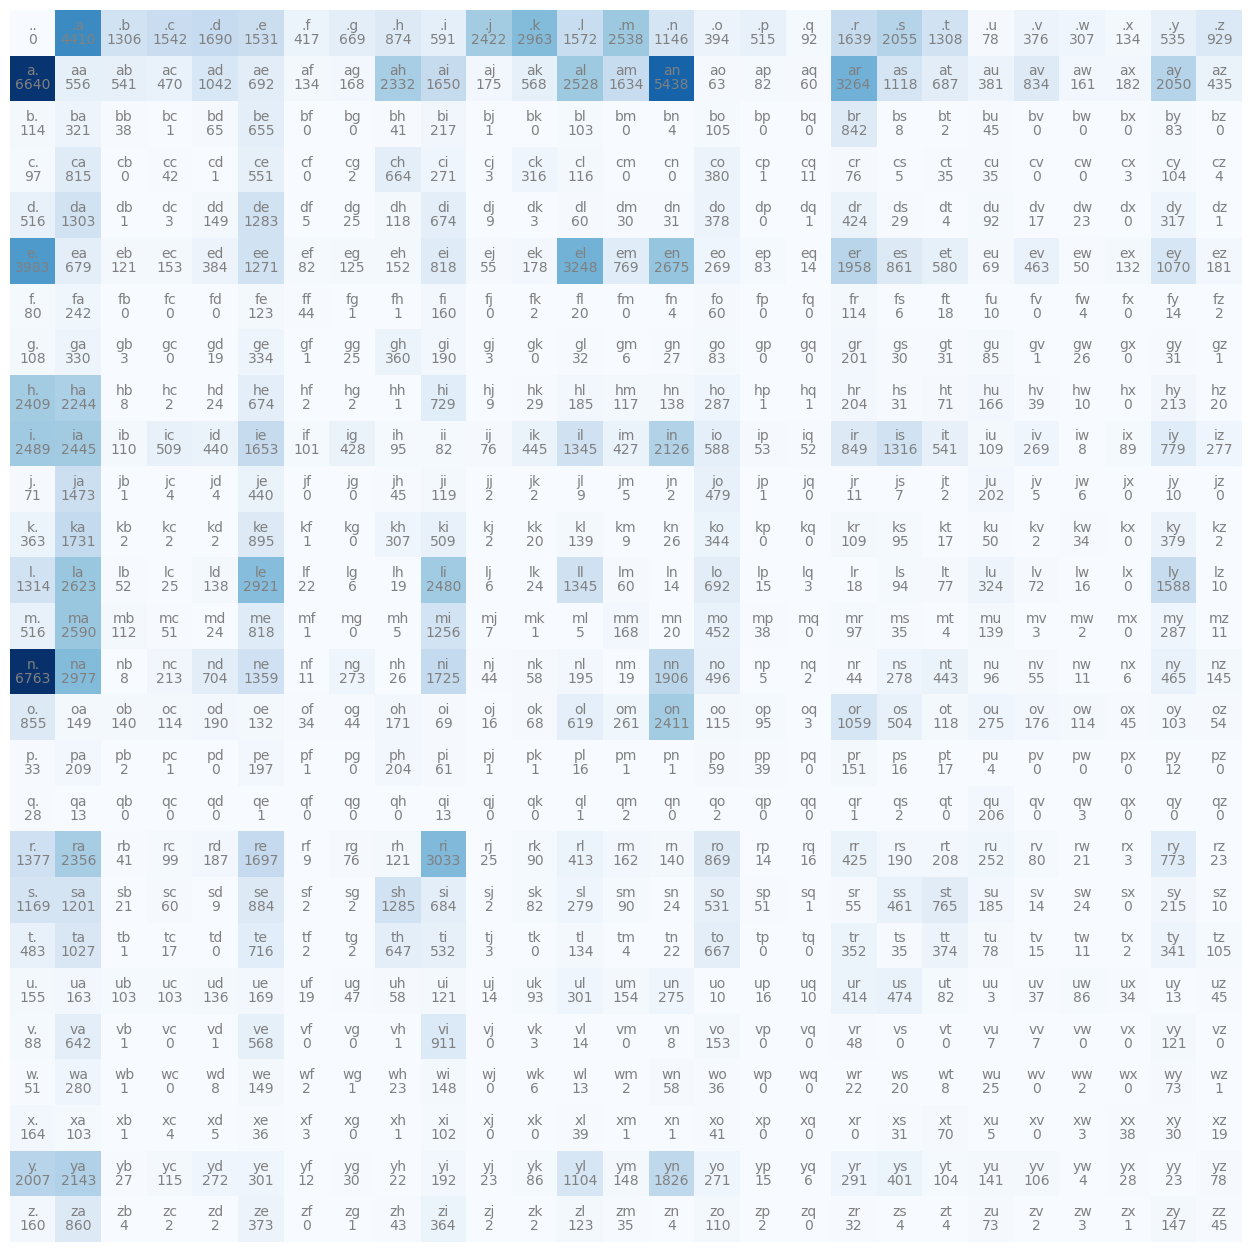

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,16))
plt.imshow(B, cmap='Blues')
for i in range(vocab_size):
    for j in range(vocab_size):
        ch = i_to_ch[i] + i_to_ch[j]
        plt.text(j, i, ch, ha="center", va="bottom", color='gray')
        plt.text(j, i, B[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off')
plt.show()

### 1.3 Sampling from the model

Each row of tensor **B** repesents a character and its columns represents the bigram frequency counts with that character being the first character in the pair. We can just divide each element of it with its row-wise sum to get the probability distribution for that particluar character.

In [14]:
P = B.float()
P /= P.sum(dim=1, keepdim=True) # creating row-wise probability distribution

In [15]:
torch.manual_seed(2147483647)

# generate 20 names until '.' (0 as int) character appears
for _ in range(20):
    ix = 0
    out = []
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True).item()
        out.append(i_to_ch[ix])
        if ix == 0:
            break

    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


### 1.4 Evaluating using loss function

Till now we have created our bigram model and done the sampling. But how good is the quality of the output given by our model?

A model is considered good if it is performing well atleast on the training dataset or the model produces the expected outputs for each input data given from the training dataset which in our case was `names.txt`. So if bigram **AB** is most likely to be formed whenever the input is **A** and our model also mostly produces **B** whenever the input is **A** then it can be considered a good model.

But our model doesn't directly produce the output character rather it gives probability for that character. For the expected output character the model should be assigning higher probabilities to it. And same should be the case for all the expected outputs when given their inputs. 

We can use a loss function that quantifies the error between a model's predicted output and the actual target (ground truth) value.

#### Loss function: Negative Log-Likelihood (NLL)

Here comes the **likelihood** estimation which basically tells "How likely does my model conditions fit the given data?".

Likelihood is calculated as product of all the probaibilties given by the model. Remember for the expected outcomes we would want our model to give higher probabilities thus we would like to maximize the value of likelihood for better data fitment.

Example:
- If our expected output is **B** for input **A** and our model assigns a **higher** probability to **B** and it does same for other inputs also then overall likelihood = p1 * p2 * ... * pn (for n inputs) will be **higher** number.
- If our expected output is **B** for input **A** and our model assigns a **lower** probability to **B** and it does same for other  inputs also then overall likelihood = p1 * p2 * ... * pn (for n inputs) will be **lower** number.

But likelihood is product of probabilities i.e. p<sub>1</sub> x p<sub>2</sub> x p<sub>3</sub> x ... x p<sub>n</sub>. Since all the probabilities are b/w 0 and 1, their product will be an even smaller number. NOT Convenient to work with.

Log likelihood is sum of log of probabilities i.e. log(p<sub>1</sub>) + log(p<sub>2</sub>) + log(p<sub>3</sub>) + ... + log(p<sub>n</sub>). Its provides a convenient way by scaling up those values. We want our loss to be minimum i.e. 0 for higher probabilities and > 0 for lower probabilities but log gives more -ve values for such probabilities. Need to invert the scale.

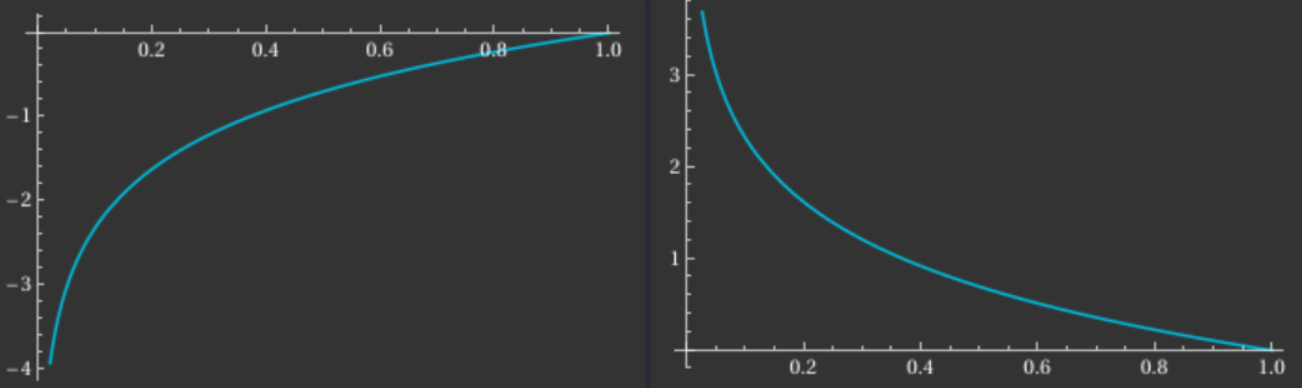

Thus we use **-log likelihood**. Its ensures 0 loss for higher probabilities and > 0 loss for lower probabilities.

#### Model smoothing

First lets calcualte the loss for single example name `andrejq`.

In [16]:
log_likelihood = 0.0
n = 0

for name in ["andrejq"]:
    chars = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chars, chars[1:]):
        ix1 = ch_to_i[ch1]
        ix2 = ch_to_i[ch2]
        prob = P[ix1, ix2]
        log = torch.log(prob)
        log_likelihood += log
        n += 1
        print(f"P({ch1}{ch2}) = {prob:.4f}, log = {log:.4f}")

print(f"log_likelihood = {log_likelihood}")
nll = -log_likelihood
print(f"nll = {nll/n}")

P(.a) = 0.1377, log = -1.9829
P(an) = 0.1605, log = -1.8296
P(nd) = 0.0384, log = -3.2594
P(dr) = 0.0771, log = -2.5620
P(re) = 0.1336, log = -2.0127
P(ej) = 0.0027, log = -5.9171
P(jq) = 0.0000, log = -inf
P(q.) = 0.1029, log = -2.2736
log_likelihood = -inf
nll = inf


The name `andrejq` being predicted by the model is very unlikely bcoz the bigram `jq` has count 0 as per the bigram model thus, the loss is `inf`. This problem can be solved with **Model smoothing** by adding fake counts.

We can just add 1 to each bigram pair so that no bigram pair have frequency count as 0. This way our model will never give 0 probability for any output character and thus the loss would never get a `inf` value. 

In [17]:
P = (B+1).float() # adding 1 to each bigram count for smoothening the model
P /= P.sum(dim=1, keepdim=True)

log_likelihood = 0.0
n = 0

for name in ["andrejq"]:
    chars = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chars, chars[1:]):
        ix1 = ch_to_i[ch1]
        ix2 = ch_to_i[ch2]
        prob = P[ix1, ix2]
        log = torch.log(prob)
        log_likelihood += log
        n += 1
        print(f"P({ch1}{ch2}) = {prob:.4f}, log = {log:.4f}")

print(f"log_likelihood = {log_likelihood}")
nll = -log_likelihood
print(f"nll = {nll}")
print(f"Loss for single example = {nll/n}")

P(.a) = 0.1376, log = -1.9835
P(an) = 0.1604, log = -1.8302
P(nd) = 0.0384, log = -3.2594
P(dr) = 0.0770, log = -2.5646
P(re) = 0.1334, log = -2.0143
P(ej) = 0.0027, log = -5.9004
P(jq) = 0.0003, log = -7.9817
P(q.) = 0.0970, log = -2.3331
log_likelihood = -27.867216110229492
nll = 27.867216110229492
Loss for single example = 3.4834020137786865


Now lets calculate the loss for the entire dataset with model smoothening.

In [18]:
P = (B+1).float() # adding 1 to each bigram count for smoothening the model
P /= P.sum(dim=1, keepdim=True)

log_likelihood = 0.0
n = 0

for name in names:
    chars = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chars, chars[1:]):
        ix1 = ch_to_i[ch1]
        ix2 = ch_to_i[ch2]
        prob = P[ix1, ix2]
        log = torch.log(prob)
        log_likelihood += log
        n += 1

print(f"log_likelihood = {log_likelihood}")
nll = -log_likelihood
print(f"nll = {nll}")
print(f"Loss over entire dataset = {nll/n}")

log_likelihood = -559951.5625
nll = 559951.5625
Loss over entire dataset = 2.4543561935424805


### 2. Neural network approach

Lets create our bigram model using a neural network based approach.

In order to train a neural network we need to do the following:
1. **prepare dataset:** In our case its `names.txt`.  
    We need to 
    - delimit every single name using special token `<.>`
    - convert our bigrams into inputs (x) and labels (y)
2. **define model architecture:** Our network will take a single character as input and outputs a probability distribution of vocab_size from which we can sample the output character. 

3. **define a loss function:** we will use NLL loss.

4. **iterate for max steps:** we will train for max_steps = 100

#### 2.0 Getting intuition

Lets do it for a single name first.

In the name `emma`, we have 5 different examples (x, y):
|x|y|
|-|-|
|.|e|
|e|m|
|m|m|
|m|a|
|a|.|

In [19]:
names[:1]

['emma']

In [20]:
for name in names[:1]:
    chars = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chars, chars[1:]):
        print(ch1, ch2)

. e
e m
m m
m a
a .


For each of these examples, we will encode the input character to get its corresponding index and store them in a tensor.

In [21]:
xs, ys = [], []

for name in names[:1]:
    chars = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chars, chars[1:]):
        ix1 = ch_to_i[ch1]
        ix2 = ch_to_i[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)


In [22]:
xs # inputs

tensor([ 0,  5, 13, 13,  1])

In [23]:
ys # labels/targets

tensor([ 5, 13, 13,  1,  0])

Once encoded, we would want our neural network to take `xs` tensor as input but we don't want to directly feed in the indices of the input characters rather we will one-hot encode them and then feed in to the network.

So previously we had 5 examples with a single int value or xs.shape is (5, 1). After one-hot encoding we will have 27 dimensions for each of these examples. So the new shape will be (5, 27). Also we need to change the dtype to `float` because one-hot encoding returns integer values.

In [24]:
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes=vocab_size).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

We will define a single layer where each neuron will now take 27 inputs. 

In [25]:
W = torch.randn((vocab_size, 1)) # a single layer with one neuron (27 inputs * 1 neuron)
W

tensor([[ 0.1275],
        [ 1.3040],
        [-1.2924],
        [-0.3443],
        [ 0.5204],
        [-1.1019],
        [ 0.5533],
        [-2.1097],
        [-0.0769],
        [ 0.4809],
        [ 0.0226],
        [-1.8464],
        [ 1.4116],
        [-0.8560],
        [-0.4427],
        [-1.4028],
        [ 0.7910],
        [ 1.7532],
        [ 0.8610],
        [ 1.7204],
        [ 1.2029],
        [-1.7312],
        [-2.2978],
        [ 0.8560],
        [-0.0485],
        [-1.0130],
        [ 0.2561]])

A single neuron will output a single number. we can increase the no. of nwurons to `vocab_size` to get a single number that can represent every unique character in out vocabulary. 

One thing to note here is that since we using one-hot encodings, only true index value is 1 rest all values are 0 so during matmul opration only the weight corresponding to the true index value will contribute and will become the result as rest of values become 0. This can also be interpreted as indexing the weights. 

In [26]:
xenc @ W # (5, 27) @ (27, 1) -> (5, 1)

tensor([[ 0.1275],
        [-1.1019],
        [-0.8560],
        [-0.8560],
        [ 1.3040]])

For each of these examples we would want our network to take the inputs and output a probability distribution of `vocab_size` for it. Then we can sample over it to get the index of the character which then can be decoded to get the actual character.

**Flow:** input character -> encode -> one-hot -> matmul -> logits -> probs (softmax) -> sample -> decode -> output character

In [27]:
W = torch.randn((vocab_size, vocab_size)) # a single layer with vocab_size no .of neurons (27 inputs * 27 neurons)
logits = xenc @ W # can be interpreted as log value of bigram freq counts
counts = logits.exp() # same as freq counts in the bigram (B) tensor above
probs = counts / counts.sum(1, keepdim=True) # same as prob dist in tensor P above
probs

tensor([[0.0459, 0.0587, 0.0149, 0.0057, 0.0015, 0.0164, 0.0254, 0.0305, 0.0283,
         0.0247, 0.0188, 0.0125, 0.1121, 0.0251, 0.0020, 0.0484, 0.1411, 0.1438,
         0.0918, 0.0236, 0.0437, 0.0167, 0.0036, 0.0180, 0.0067, 0.0293, 0.0107],
        [0.0177, 0.0152, 0.0019, 0.0413, 0.0129, 0.0796, 0.0419, 0.0445, 0.0190,
         0.0852, 0.0793, 0.0538, 0.0840, 0.0357, 0.0048, 0.0572, 0.0181, 0.0271,
         0.0435, 0.0107, 0.0320, 0.0460, 0.0449, 0.0198, 0.0456, 0.0047, 0.0337],
        [0.0184, 0.0427, 0.0314, 0.0178, 0.0326, 0.1048, 0.0283, 0.0125, 0.0365,
         0.0565, 0.0069, 0.0049, 0.1416, 0.0094, 0.0717, 0.0113, 0.0299, 0.0137,
         0.0098, 0.0281, 0.0074, 0.0240, 0.0281, 0.0368, 0.1521, 0.0276, 0.0153],
        [0.0184, 0.0427, 0.0314, 0.0178, 0.0326, 0.1048, 0.0283, 0.0125, 0.0365,
         0.0565, 0.0069, 0.0049, 0.1416, 0.0094, 0.0717, 0.0113, 0.0299, 0.0137,
         0.0098, 0.0281, 0.0074, 0.0240, 0.0281, 0.0368, 0.1521, 0.0276, 0.0153],
        [0.0194, 0.0327,

#### 2.1 Training

In [28]:
# creating dataset

xs, ys = [], []
for name in names:
    chars = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chars, chars[1:]):
        ix1 = ch_to_i[ch1]
        ix2 = ch_to_i[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
print(f"total num of examples: {xs.nelement()}")

total num of examples: 228146


In [29]:
# initializing model

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)

class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()

        self.W = nn.Linear(vocab_size, vocab_size, bias=False)
    
    def forward(self, xs, targets=None):
        xenc = F.one_hot(xs, num_classes=vocab_size).float()
        logits = self.W(xenc)
        loss = None
        if targets != None:
            loss = F.cross_entropy(logits, targets)
        return logits, loss

model = BigramLanguageModel(vocab_size)
print(f"No. of params: {sum(p.numel() for p in model.parameters())}")

optimizer = torch.optim.AdamW(model.parameters(), lr=0.1)

No. of params: 729


In [30]:
# training the model
max_steps = 100

for step in range(max_steps):
    logits, loss = model(xs, ys)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if step % 5 == 0 or step == max_steps-1:
        print(f"step: {step}, loss: {loss.item():.4f}")

step: 0, loss: 3.2911
step: 5, loss: 2.8717
step: 10, loss: 2.6412
step: 15, loss: 2.5349
step: 20, loss: 2.4932
step: 25, loss: 2.4791
step: 30, loss: 2.4715
step: 35, loss: 2.4659
step: 40, loss: 2.4625
step: 45, loss: 2.4605
step: 50, loss: 2.4591
step: 55, loss: 2.4582
step: 60, loss: 2.4575
step: 65, loss: 2.4571
step: 70, loss: 2.4568
step: 75, loss: 2.4565
step: 80, loss: 2.4563
step: 85, loss: 2.4562
step: 90, loss: 2.4561
step: 95, loss: 2.4559
step: 99, loss: 2.4559


Even though the NN based approach tends to acheive the similar loss as that of the tabular bigram approach (where we explicitly counted bigram freqs and normalized it to get probs) the gradient based approach is still better as its scalable to the no. input context i.e. we can scale it to get the output char based on a no. of previous input char, say 10 previous characters. This scalability is very difficult to implement & visualize in tabular based approach due to the large no. of char combination present. 

#### 2.2 Sampling

In [31]:
# sample 5 names

for _ in range(5):
    out = []
    ix = 0
    while True:
        logits, loss = model(torch.tensor([ix]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        out.append(i_to_ch[ix])
        if ix == 0:
            break
    
    print(''.join(out))

daieiaaesaferleydratzobreeayurenn.
r.
soulyeen.
annieiceshadalah.
itldy.
